### ECE 1505 Convex Optimization Project: figures

The methodology and backtests are in Data_ChangeDetection.ipynb; this notebook makes the rebalancing-times figure used in the report (`Images/cp.png`).

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

from data import load_prices
from changepoint import retrieve_rebalancing_info
sns.set_style('whitegrid')
%matplotlib inline

In [2]:
P, R = load_prices()

In [3]:
filename = 'Results/0.075_1000_60.pkl'
info = retrieve_rebalancing_info(filename, len(P))
print(P.index[info['res_times_updated']])
print(R.index[info['post_detection_times_updated']])

DatetimeIndex(['2012-07-13', '2012-10-11', '2013-01-17', '2013-04-24',
               '2013-07-25', '2013-10-24', '2014-01-29', '2014-05-01',
               '2014-08-01', '2014-11-07', '2015-03-05', '2015-06-12',
               '2015-10-08', '2016-01-12', '2016-04-13', '2016-07-15',
               '2016-10-18', '2017-01-24', '2017-04-26', '2017-07-28',
               '2017-10-31', '2018-02-02', '2018-05-04', '2018-08-09',
               '2018-11-23', '2019-03-01', '2019-05-31', '2019-09-16',
               '2019-12-26'],
              dtype='datetime64[ns]', name='Date', freq=None)
DatetimeIndex(['2012-04-19', '2012-07-19', '2012-10-19', '2013-01-29',
               '2013-05-01', '2013-08-01', '2013-11-01', '2014-02-05',
               '2014-05-08', '2014-08-15', '2014-12-08', '2015-03-19',
               '2015-07-16', '2015-10-16', '2016-01-19', '2016-04-21',
               '2016-07-26', '2016-10-27', '2017-01-31', '2017-05-04',
               '2017-08-08', '2017-11-07', '2018-02-08',

In [4]:
def plot_times(R, P, post_detection_times, res_times, savefile=None):
    '''makes a plot of all the stock returns along
    with the rebalancing times (P index) and estimation/posterior changepoint times (R index)'''
    R.plot(legend =False, alpha = 0.05, color = 'orange', figsize = (12,4), ylim = (-0.5, 0.5))

    for i in post_detection_times:
        plt.axvline(x=R.index[i], color = 'grey', linewidth = 4)

    for i in res_times:
        plt.axvline(x=P.index[i], linewidth =5, color = '#005aff')
    plt.title("Detected Rebalancing Times Using DRCP")
    if savefile:
        plt.savefig(savefile)

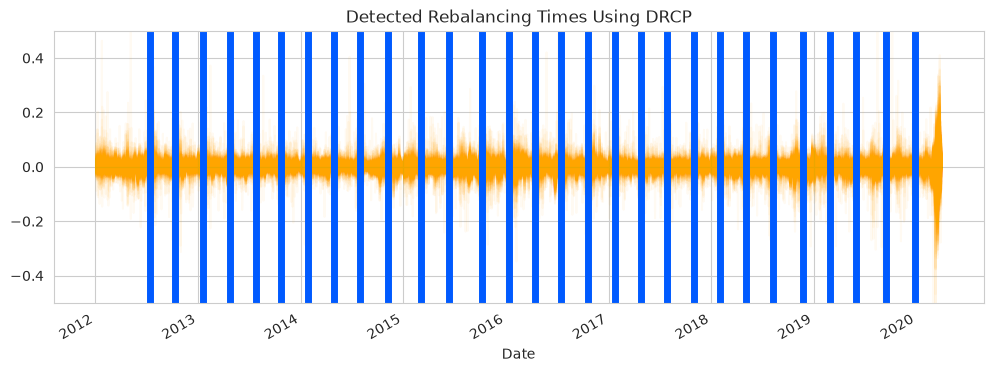

In [5]:
#blue is the rebalance time
plot_times(R, P, [], info['res_times_updated'], savefile="Images/cp.png")

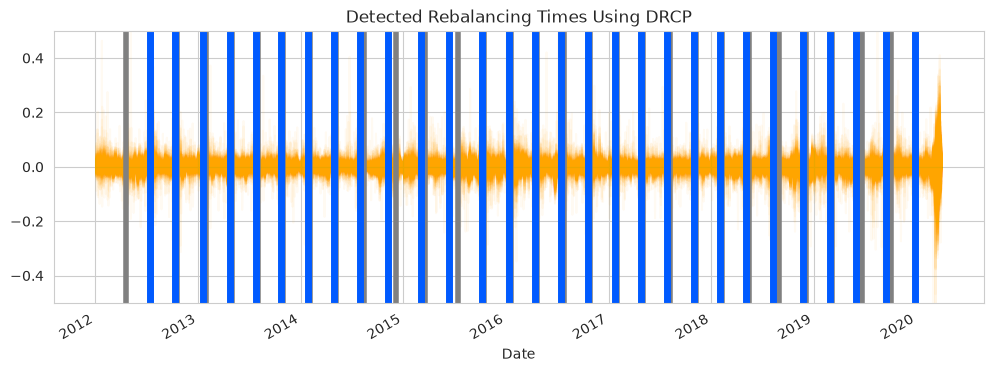

In [6]:
#grey is the estimated change point and blue the rebalance time after the estimation interval
plot_times(R, P, info['post_detection_times_updated'], info['res_times_updated'])